In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import os
import pandas as pd
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import json
import math
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec

from matplotlib.patches import Rectangle

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN, Ablation
from bioplnn.datasets import Mazes
from bioplnn.utils import (
    initialize_dataloader,
)

maze_data_path = "./data/mazes/"
checkpoint_path = "./train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

dataset = "mazes"

batch_size = 1024
train_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset="mazes"
)

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)
        self.gap   = nn.AdaptiveAvgPool2d(1)     # <- NEW
        self.fc1   = nn.Linear(128, 512)          # <- 64 channels only
        self.fc2   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.gap(x)                          # [B, 64, 1, 1]
        x = torch.flatten(x, 1)                  # [B, 64]
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
    
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20
        
    try:
        if full_cfg["model_type"] == "cnn":
            model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
            classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        else:
            model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
            classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    except:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)

        # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

    try:
        state_dict = state_dict["model_state"]
    except:
        pass

    model.load_state_dict(prepare_rnn_weights(state_dict))
    classifier.load_state_dict(state_dict)

    return model, classifier, num_steps, full_cfg, state_dict

In [4]:
## CORRELATED DOTS ##

wandb_name, checkpoint = "fancy-silence-24", 370 #BIOPLNN
# wandb_name, checkpoint = "glowing-deluge-31", 330 #CNN

## MAZES ##

wandb_name, checkpoint = "golden-universe-515", 320 # ReLU, with I->I recurrence
# wandb_name, checkpoint = "young-totem-460", 480 # ReLU, I->I recurrence, Center-Excitation
wandb_name, checkpoint = "dauntless-elevator-522", 390 #Identity interneuron


# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint_path)

/tmp/ipykernel_1258584/635104040.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locatio

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from math import ceil

def plot_kernel_grid(
    weights,
    *,
    in_labels=None,
    out_labels=None,
    normalize=True,
    vmin=None,
    vmax=None,
    cmap="seismic",
    figscale=1.0,
    pad=0.1,
    savepath=None,
    show=True,
    title=""
):
    """
    Plot a grid of kernels: cell (i, j) shows kernel from input channel i to output channel j.

    Args:
        weights: Tensor/array of shape (n_out, n_in, kx, ky). Torch or NumPy.
        in_labels: Optional list of length n_in for row labels (input channels).
        out_labels: Optional list of length n_out for column labels (output channels).
        normalize: If True, use symmetric vmin/vmax from global max(|w|).
        vmin, vmax: Optional overrides for color scaling (ignored if normalize=True and these are None).
        cmap: Matplotlib colormap.
        figscale: Scales overall figure size (useful for large channel counts).
        pad: Padding between subplots (in inches).
        savepath: If set, path to save the figure (e.g., "kernels.png").
        show: If True, plt.show() at the end.

    Returns:
        (fig, axes): Matplotlib Figure and Axes array of shape (n_in, n_out).
    """
    # Convert to NumPy
    if isinstance(weights, torch.Tensor):
        W = weights.detach().cpu().numpy()
    else:
        W = np.asarray(weights)

    assert W.ndim == 4, f"Expected (n_out, n_in, kx, ky), got shape {W.shape}"
    n_out, n_in, kx, ky = W.shape

    # Color scale
    if normalize:
        amax = np.abs(W).max()
        vmin_, vmax_ = -amax if amax > 0 else -1.0, amax if amax > 0 else 1.0
    else:
        vmin_ = vmin
        vmax_ = vmax

    # Figure size: a small multiple per cell, scaled
    cell_size = 1.0 * figscale
    fig_w = max(4.0, n_out * cell_size)
    fig_h = max(3.5, n_in  * cell_size)
    fig, axes = plt.subplots(
        n_in, n_out,
        figsize=(fig_w, fig_h),
        squeeze=False
    )

    # Tight layout tweaks
    plt.subplots_adjust(wspace=0.15, hspace=0.15)

    # Plot each kernel slice at (row=i, col=j) = (input i, output j)
    for i in range(n_in):
        for j in range(n_out):
            ax = axes[i, j]
            kern = W[j, i]  # (kx, ky)
            im = ax.imshow(kern, cmap=cmap, vmin=vmin_, vmax=vmax_, origin="upper")
            ax.set_xticks([])
            ax.set_yticks([])
            # light frame
            for spine in ax.spines.values():
                spine.set_linewidth(0.5)
                spine.set_alpha(0.5)

    # Labels on outer edges (optional)
    if out_labels is None:
        out_labels = [f"out {j}" for j in range(n_out)]
    if in_labels is None:
        in_labels = [f"in {i}" for i in range(n_in)]

    # Column titles (top row)
    for j in range(n_out):
        axes[0, j].set_title(out_labels[j], fontsize=10, pad=6)

    # Row labels (leftmost col)
    for i in range(n_in):
        axes[i, 0].set_ylabel(in_labels[i], fontsize=10, rotation=0, labelpad=12, va="center")

    # Shared colorbar (right side)
    # Make a single colorbar using the last imshow handle
    cbar = fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02)
    cbar.ax.tick_params(labelsize=8)

    # Extra padding around the whole figure
    fig.tight_layout(pad=pad)
    fig.suptitle(title, fontsize=14, y=1.04)

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    if show:
        plt.show()

    return fig, axes


In [21]:
# weights are out_channels, in_channels, kx, ky

In [9]:
input2e_name = "rnn.areas.0.convs.0->0.0.weight"
input2i_name = "rnn.areas.0.convs.0->1.0.weight"
e2e_name = "rnn.areas.0.convs.1->0.0.weight"
e2i_name = "rnn.areas.0.convs.1->1.0.weight"
i2i_name = "rnn.areas.0.convs.2->1.0.weight"
i2e_name = "rnn.areas.0.convs.2->0.0.weight"

In [10]:
e2e = state_dict[e2e_name].detach().cpu().numpy()
input2e = state_dict[input2e_name].detach().cpu().numpy()
input2i = state_dict[input2i_name].detach().cpu().numpy()
e2i = state_dict[e2i_name].detach().cpu().numpy()
i2i = state_dict[i2i_name].detach().cpu().numpy() * -1 
i2e = state_dict[i2e_name].detach().cpu().numpy() * -1

/tmp/ipykernel_1258584/395386271.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=pad)


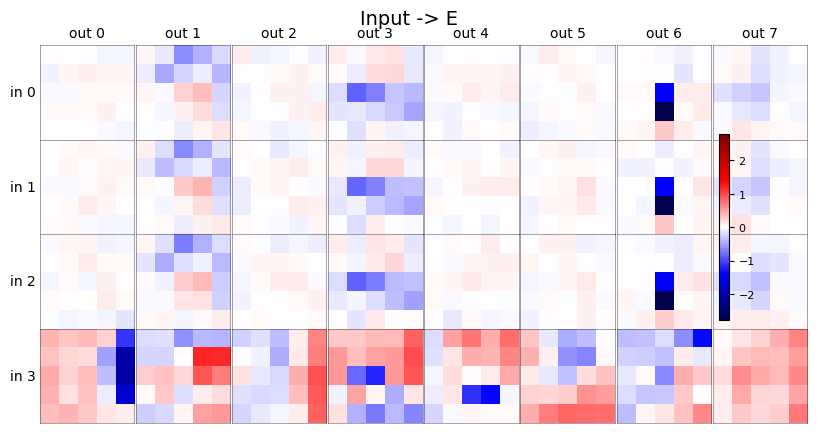

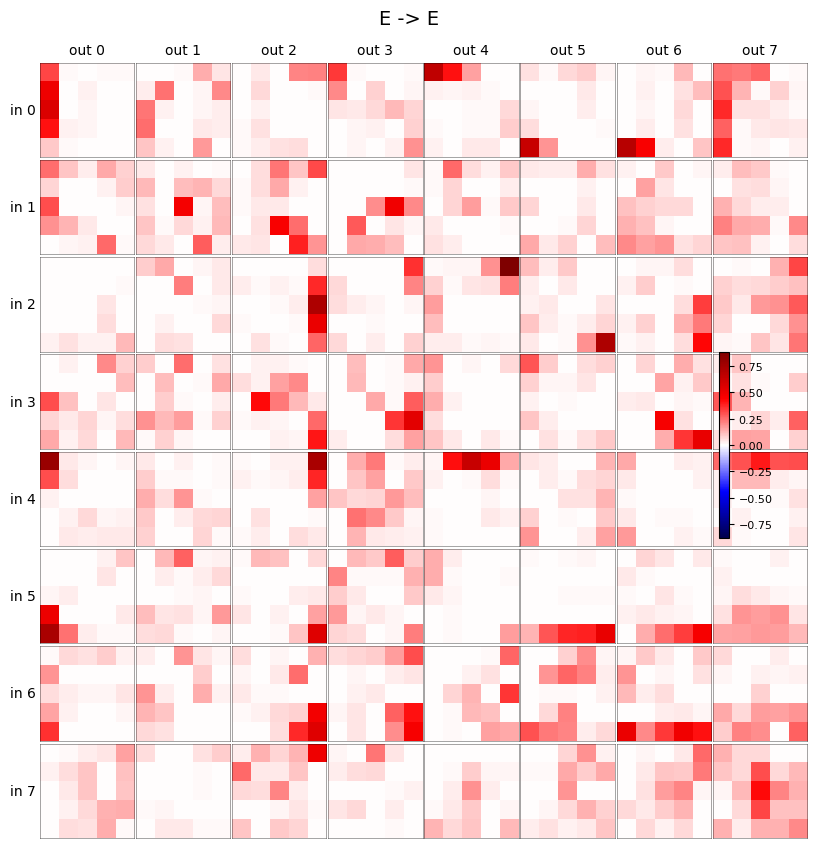

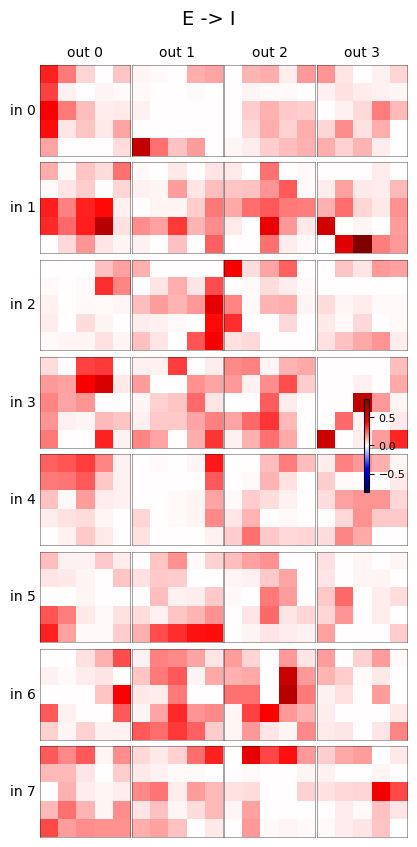

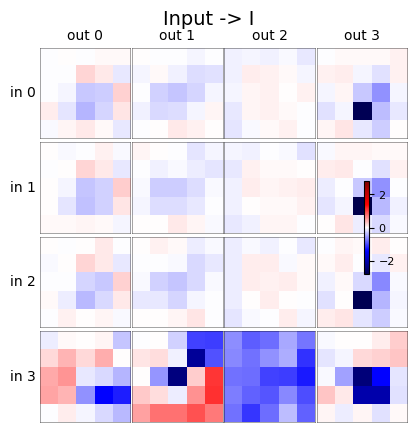

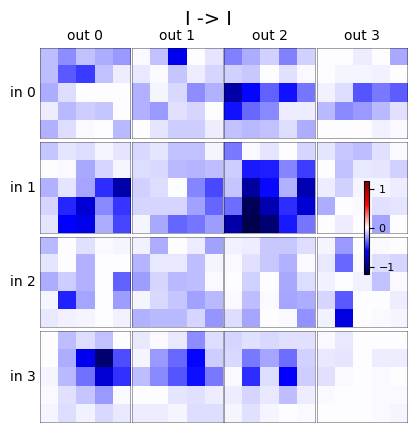

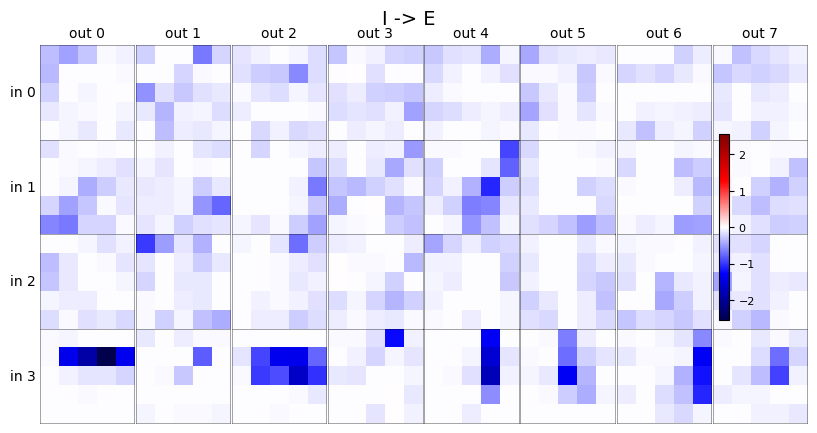

(<Figure size 800x400 with 33 Axes>,
 array([[<Axes: title={'center': 'out 0'}, ylabel='in 0'>,
         <Axes: title={'center': 'out 1'}>,
         <Axes: title={'center': 'out 2'}>,
         <Axes: title={'center': 'out 3'}>,
         <Axes: title={'center': 'out 4'}>,
         <Axes: title={'center': 'out 5'}>,
         <Axes: title={'center': 'out 6'}>,
         <Axes: title={'center': 'out 7'}>],
        [<Axes: ylabel='in 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='in 2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='in 3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [11]:
plot_kernel_grid(input2e, title="Input -> E")
plot_kernel_grid(e2e, title="E -> E")
plot_kernel_grid(e2i, title="E -> I")
plot_kernel_grid(input2i, title="Input -> I")
plot_kernel_grid(i2i, title="I -> I")
plot_kernel_grid(i2e, title="I -> E")